#
# Olist E-Commerce: What's Driving Bad Reviews & How to Fix It

A data-driven analysis of delivery performance, seller quality, and customer satisfaction using ~100k real orders

"Olist is Brazil's largest e-commerce marketplace. With thousands of sellers and millions of orders, understanding what drives negative customer experiences is critical to retention and revenue. This analysis identifies the root causes of low review scores and provides actionable recommendations."












In [1]:
 import pandas as pd
 import numpy as np

 import matplotlib.pyplot as plt
 import seaborn as sns

 import sqlite3

 pd.set_option('display.max_columns',None)
 sns.set(style='whitegrid')

 conn=sqlite3.connect('ecommerce.db')

In [2]:
# Fix: Handling bad lines that cause ParserError (e.g., unexpected extra commas)
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv", on_bad_lines='warn')
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")

In [3]:
orders.to_sql('orders', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')




99224

In [4]:
# Data Overview
for name, df in [('orders', orders), ('customers', customers),
                  ('order_items', order_items), ('payments', payments),
                  ('products', products), ('reviews', reviews)]:
    print(f"\n{'='*40}")
    print(f"{name.upper()}: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


ORDERS: 99441 rows, 8 columns
Nulls:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

CUSTOMERS: 99441 rows, 5 columns
Nulls:
Series([], dtype: int64)

ORDER_ITEMS: 112650 rows, 7 columns
Nulls:
Series([], dtype: int64)

PAYMENTS: 103886 rows, 5 columns
Nulls:
Series([], dtype: int64)

PRODUCTS: 32951 rows, 9 columns
Nulls:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

REVIEWS: 99224 rows, 7 columns
Nulls:
review_comment_title      87656
review_comment_message    58247
dtype: int64


In [5]:
# Convert date columns to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [6]:
# Calculate actual delivery days and delay
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

orders['delay_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

# Positive = late, Negative = early

In [7]:
# Keeping only delivered orders for analysis
delivered = orders[orders['order_status'] == 'delivered'].copy()
print(f"Delivered orders: {len(delivered)} out of {len(orders)}")

Delivered orders: 96478 out of 99441


** Analysis is based on 96,478 delivered orders (97% of total).
> Cancelled and undelivered orders are excluded as review scores are not applicable.

In [9]:
delivered.to_sql('orders_clean', conn, index=False, if_exists='replace')

96478

## Analysis 1: Does Delivery Time Affect Review Scores?

In [10]:
query1 = """
SELECT
    CASE
        WHEN delivery_days <= 7 THEN '0-7 days'
        WHEN delivery_days <= 14 THEN '8-14 days'
        WHEN delivery_days <= 21 THEN '15-21 days'
        ELSE '21+ days'
    END AS delivery_bucket,
    COUNT(*) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
GROUP BY delivery_bucket
ORDER BY avg_review_score DESC
"""

result1 = pd.read_sql(query1, conn)
print(result1)

  delivery_bucket  total_orders  avg_review_score
0        0-7 days         33683              4.41
1       8-14 days         36395              4.29
2      15-21 days         15381              4.10
3        21+ days         10902              3.01


/tmp/ipykernel_350/572438339.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result1, x='delivery_bucket', y='avg_review_score',


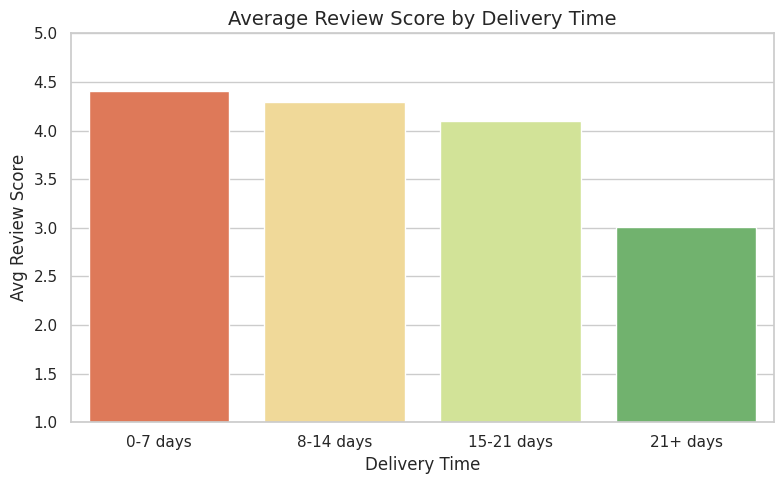

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(data=result1, x='delivery_bucket', y='avg_review_score',
            order=['0-7 days','8-14 days','15-21 days','21+ days'],
            palette='RdYlGn')
plt.title('Average Review Score by Delivery Time', fontsize=14)
plt.xlabel('Delivery Time')
plt.ylabel('Avg Review Score')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

###  Finding 1:
Delivery time is strongly correlated with customer satisfaction.
- Orders delivered in 0-7 days → avg score 4.41 (33,683 orders)
- Orders taking 21+ days → avg score 3.01 (10,902 orders)
- A 32% drop in satisfaction for slow deliveries.
- 11% of all delivered orders (10,902) fall in the 21+ days bucket

## Analysis 2: Does Arriving Late (vs Promised Date) Affect Reviews?

In [12]:
query2 = """
SELECT
    CASE
        WHEN delay_days < 0 THEN 'Early'
        WHEN delay_days = 0 THEN 'On Time'
        WHEN delay_days <= 7 THEN 'Late (1-7 days)'
        ELSE 'Very Late (7+ days)'
    END AS delay_bucket,
    COUNT(*) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
GROUP BY delay_bucket
ORDER BY avg_review_score DESC
"""

result2 = pd.read_sql(query2, conn)
print(result2)

          delay_bucket  total_orders  avg_review_score
0                Early         88653              4.29
1              On Time          1291              4.03
2      Late (1-7 days)          3612              2.71
3  Very Late (7+ days)          2805              1.71


/tmp/ipykernel_350/1832289145.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result2, x='delay_bucket', y='avg_review_score',


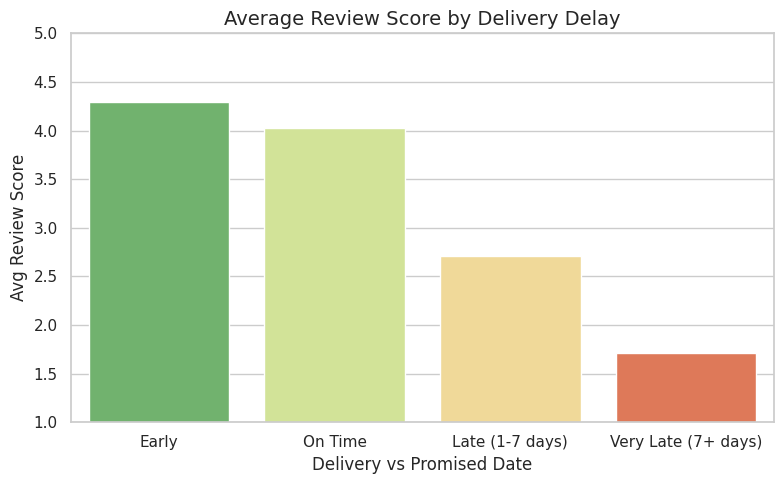

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(data=result2, x='delay_bucket', y='avg_review_score',
            order=['Early', 'On Time', 'Late (1-7 days)', 'Very Late (7+ days)'],
            palette='RdYlGn_r')
plt.title('Average Review Score by Delivery Delay', fontsize=14)
plt.xlabel('Delivery vs Promised Date')
plt.ylabel('Avg Review Score')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

###  Finding 2:
Arriving late relative to the promised date devastates review scores.
- Early deliveries → 4.29 avg score (88,653 orders — 92% of delivered orders)
- Very late (7+ days past promise) → 1.71 avg score (2,805 orders)
- A 60% drop in satisfaction.
- Surprisingly, "On Time" scores lower than "Early" — customers reward
  beating expectations, not just meeting them.

## Analysis 3: Which Product Categories Have the Worst Review Scores?

In [14]:
query3 = """
SELECT
    p.product_category_name AS category,
    COUNT(*) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    ROUND(AVG(o.delivery_days), 1) AS avg_delivery_days
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
JOIN order_items oi ON o.order_id = oi.order_id
JOIN products p ON oi.product_id = p.product_id
WHERE p.product_category_name IS NOT NULL
GROUP BY category
HAVING COUNT(*) > 100
ORDER BY avg_review_score ASC
LIMIT 10
"""

result3 = pd.read_sql(query3, conn)
print(result3)

                           category  total_orders  avg_review_score  \
0                 moveis_escritorio          1664              3.52   
1           fashion_roupa_masculina           124              3.76   
2                    telefonia_fixa           253              3.76   
3                             audio           359              3.83   
4                     casa_conforto           430              3.85   
5                   cama_mesa_banho         10985              3.92   
6                       moveis_sala           494              3.94   
7                  moveis_decoracao          8159              3.95   
8                   casa_construcao           593              3.96   
9  construcao_ferramentas_seguranca           182              3.97   

   avg_delivery_days  
0               20.4  
1               12.3  
2               12.2  
3               12.9  
4               13.0  
5               12.3  
6               13.3  
7               12.3  
8          

/tmp/ipykernel_350/4005462316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result3, x='avg_review_score', y='category', palette='RdYlGn')


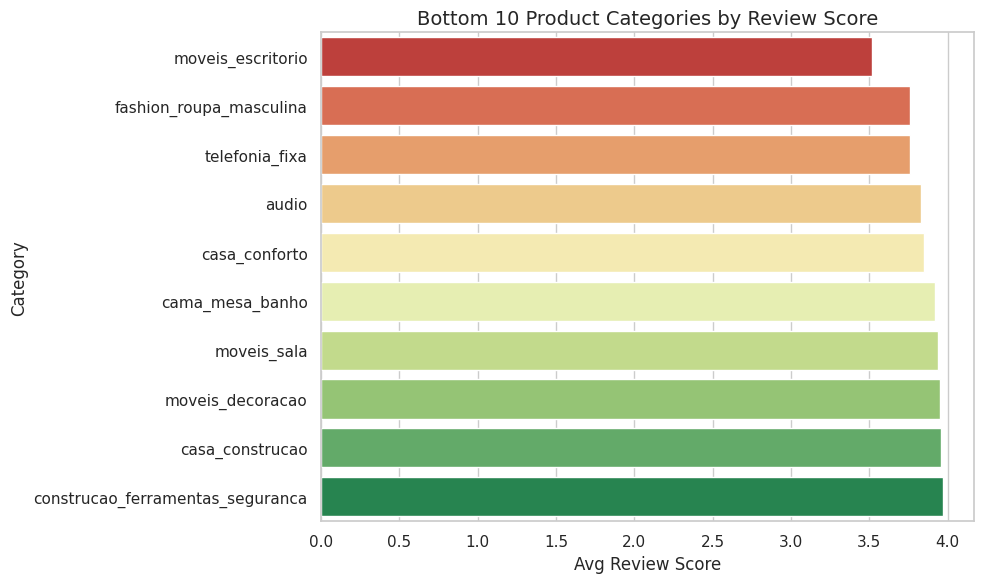

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(data=result3, x='avg_review_score', y='category', palette='RdYlGn')
plt.title('Bottom 10 Product Categories by Review Score', fontsize=14)
plt.xlabel('Avg Review Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

###  Finding 3:
Office furniture (moveis_escritorio) is the worst performing category:
- Avg review score of 3.52 vs ~3.9 for other bottom categories
- Avg delivery time of 20.4 days vs ~12-13 days for others
- Heavy/bulky items take longer to deliver — directly hurting satisfaction
- cama_mesa_banho (bed/bath) has 10,985 orders at 3.92 — high volume,
  low satisfaction — a priority fix for Olist

## Analysis 4: Which States Have the Worst Delivery Performance?

In [22]:
query4 = """
SELECT
    c.customer_state AS state,
    COUNT(*) AS total_orders,
    ROUND(AVG(o.delivery_days), 1) AS avg_delivery_days,
    ROUND(AVG(r.review_score), 2) AS avg_review_score
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY state
HAVING COUNT(*) > 200
ORDER BY avg_delivery_days DESC
LIMIT 10
"""

result4 = pd.read_sql(query4, conn)
print(result4)

  state  total_orders  avg_delivery_days  avg_review_score
0    AL           398               23.9              3.84
1    PA           939               23.2              3.91
2    SE           334               20.9              3.91
3    MA           716               20.9              3.84
4    CE          1276               20.8              3.94
5    PB           513               19.8              4.08
6    PI           472               19.0              4.00
7    RO           242               18.9              4.17
8    RN           473               18.8              4.15
9    BA          3246               18.8              3.93


/tmp/ipykernel_350/1535713024.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result4, x='avg_delivery_days', y='state',
/tmp/ipykernel_350/1535713024.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result4, x='avg_review_score', y='state',


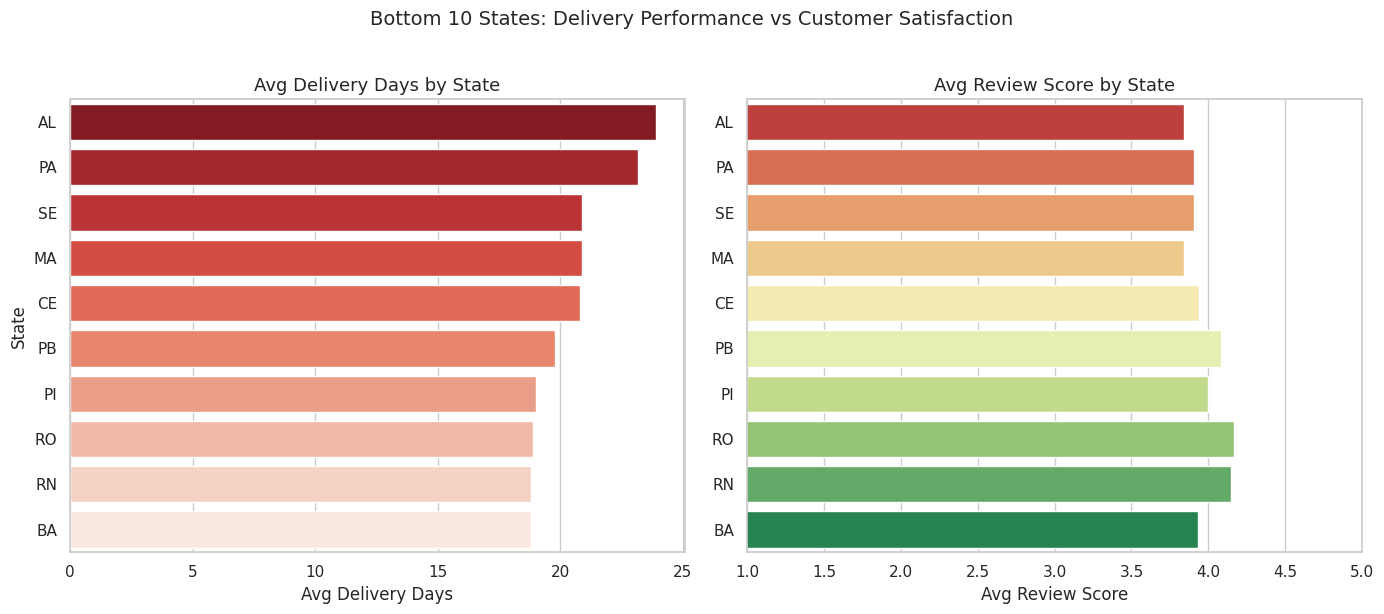

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# Left chart - Delivery Days
sns.barplot(data=result4, x='avg_delivery_days', y='state',
            palette='Reds_r', ax=ax1)
ax1.set_title('Avg Delivery Days by State', fontsize=13)
ax1.set_xlabel('Avg Delivery Days')
ax1.set_ylabel('State')

# Right chart - Review Score
sns.barplot(data=result4, x='avg_review_score', y='state',
            palette='RdYlGn', ax=ax2)
ax2.set_title('Avg Review Score by State', fontsize=13)
ax2.set_xlabel('Avg Review Score')
ax2.set_ylabel('')
ax2.set_xlim(1, 5)

plt.suptitle('Bottom 10 States: Delivery Performance vs Customer Satisfaction',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

###  Finding 4:
The worst delivery performance is concentrated in Northern/Northeast Brazil.
- AL (Alagoas) averages 23.9 days — the slowest state
- Top 5 slowest states are all in the North/Northeast region
- These states likely lack Olist warehouse/logistics presence nearby
- BA (Bahia) has 3,246 orders at 18.8 days — highest volume + slow delivery
  = biggest regional priority to fix

## Analysis 5: Seller Performance — Who is Hurting Olist the Most?

In [25]:
query5 = """
SELECT
    oi.seller_id,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    ROUND(AVG(o.delivery_days), 1) AS avg_delivery_days,
    ROUND(SUM(oi.price), 2) AS total_revenue
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
JOIN order_items oi ON o.order_id = oi.order_id
GROUP BY oi.seller_id
HAVING COUNT(DISTINCT o.order_id) > 50
ORDER BY avg_review_score ASC
LIMIT 10
"""

result5 = pd.read_sql(query5, conn)
print(result5)

                          seller_id  total_orders  avg_review_score  \
0  1ca7077d890b907f89be8c954a02686a           107              2.27   
1  2eb70248d66e0e3ef83659f71b244378           184              2.81   
2  972d0f9cf61b499a4812cf0bfa3ad3c4            79              2.96   
3  a49928bcdf77c55c6d6e05e09a9b4ca5            96              2.97   
4  8e6d7754bc7e0f22c96d255ebda59eba            84              3.03   
5  bbad7e518d7af88a0897397ffdca1979            67              3.05   
6  54965bbe3e4f07ae045b90b0b8541f52            69              3.07   
7  5058e8c1e82653974541e83690655b4a            61              3.08   
8  8444e55c1f13cd5c179851e5ca5ebd00            92              3.16   
9  b2479f944e1b90cf8a5de1bbfde284d6           100              3.32   

   avg_delivery_days  total_revenue  
0               14.5       12324.64  
1               17.4       37749.85  
2               17.9        7748.79  
3               16.5        8646.90  
4               13.6       1

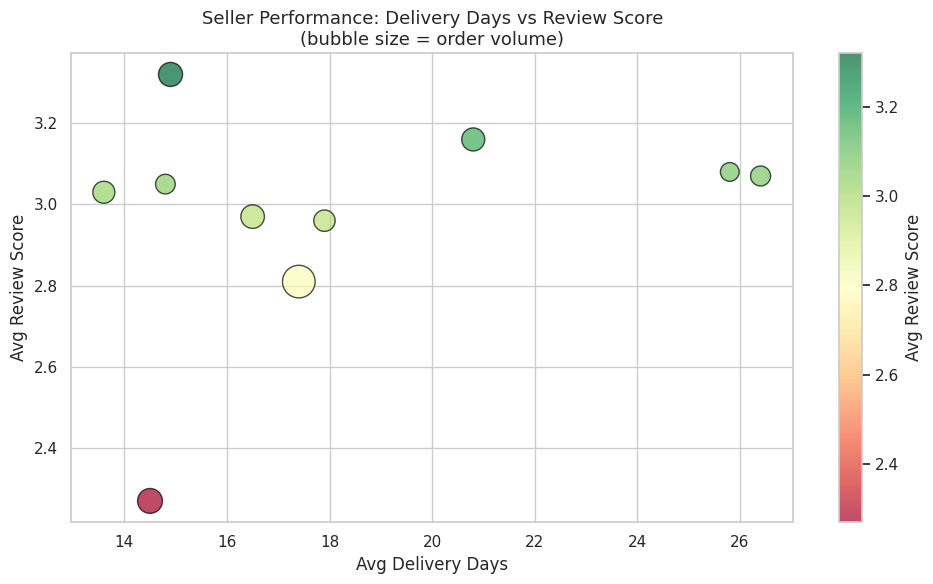

In [26]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(
    result5['avg_delivery_days'],
    result5['avg_review_score'],
    s=result5['total_orders'] * 3,
    c=result5['avg_review_score'],
    cmap='RdYlGn',
    alpha=0.7,
    edgecolors='black'
)
plt.colorbar(scatter, label='Avg Review Score')
plt.title('Seller Performance: Delivery Days vs Review Score\n(bubble size = order volume)', fontsize=13)
plt.xlabel('Avg Delivery Days')
plt.ylabel('Avg Review Score')
plt.tight_layout()
plt.show()

###  Finding 5:
10 sellers with 50+ orders are averaging below 3.4 review score.
- Worst seller scores 2.27 despite average delivery time —
  suggesting product quality issues beyond logistics
- Highest risk seller has 184 orders and 37,749 BRL revenue at 2.81 score
- These sellers are actively damaging Olist's platform reputation
- Olist should implement a seller scorecard system with minimum
  review score thresholds

## Analysis 6: Does Payment Method Affect Review Scores?

In [28]:
query6 = """
SELECT
    p.payment_type,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(AVG(r.review_score), 2) AS avg_review_score,
    ROUND(AVG(o.delivery_days), 1) AS avg_delivery_days
FROM orders_clean o
JOIN reviews r ON o.order_id = r.order_id
JOIN payments p ON o.order_id = p.order_id
GROUP BY p.payment_type
ORDER BY avg_review_score DESC
"""

result6 = pd.read_sql(query6, conn)
print(result6)

  payment_type  total_orders  avg_review_score  avg_delivery_days
0   debit_card          1478              4.24               10.3
1       boleto         19062              4.16               13.0
2  credit_card         73808              4.15               11.9
3      voucher          3648              4.11               12.2


/tmp/ipykernel_350/2554948279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result6, x='payment_type', y='avg_review_score',


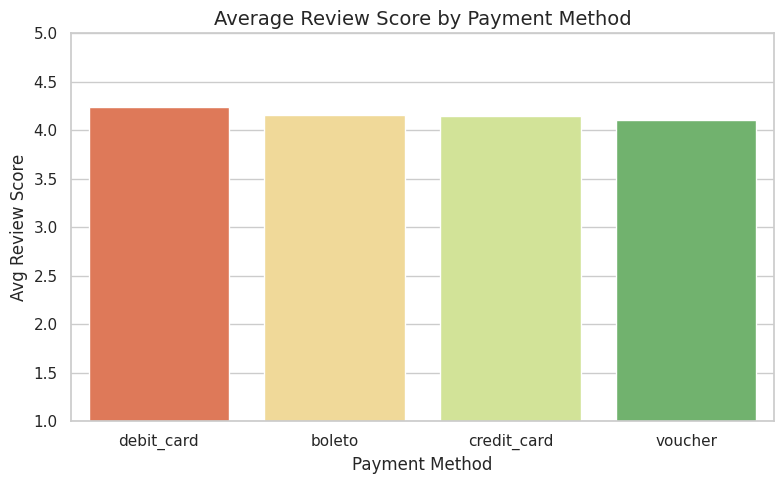

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(data=result6, x='payment_type', y='avg_review_score',
            palette='RdYlGn')
plt.title('Average Review Score by Payment Method', fontsize=14)
plt.xlabel('Payment Method')
plt.ylabel('Avg Review Score')
plt.ylim(1, 5)
plt.tight_layout()
plt.show()

###  Finding 6:
Payment method has minimal impact on review scores (range: 4.11–4.24).
- Credit card dominates with 73,808 orders (76% of all payments)
- Debit card users receive faster delivery (10.3 days avg) and rate highest
- Payment method is NOT a significant driver of customer dissatisfaction
- Focus should remain on delivery time and seller quality for improving scores

Based on the analysis of 96,478 delivered orders, here are 5 actionable
recommendations for Olist to improve customer satisfaction:

---

### 🎯 Recommendation 1: Prioritize Same-Week Delivery
- Orders delivered in 0-7 days score 4.41 vs 3.01 for 21+ days
- Olist should expand warehouse presence in slow regions to cut delivery time
- Target: Reduce 21+ day orders (currently 11% of all orders) by 50%

---

### 🎯 Recommendation 2: Fix the Promise — Don't Just Fix the Delivery
- Very late orders (7+ days past promise) score just 1.71
- Olist should improve delivery date estimation accuracy
- Even if delivery is slow, meeting the promised date protects satisfaction
- Target: Eliminate Very Late category entirely through better ETA algorithms

---

### 🎯 Recommendation 3: Open Logistics Hubs in North/Northeast Brazil
- AL, PA, SE, MA, CE are averaging 20+ delivery days
- These states have significant order volumes but no nearby fulfillment centers
- BA alone has 3,246 orders at 18.8 days — highest priority state to fix

---

### 🎯 Recommendation 4: Implement a Seller Scorecard System
- 10+ sellers with high order volumes are averaging below 3.4 review score
- Worst seller scores 2.27 despite average delivery time — product quality issue
- Olist should set minimum score threshold of 3.5 for active sellers
- Sellers below threshold should receive warnings, then suspension

---

### 🎯 Recommendation 5: Fix High-Volume Low-Score Categories
- cama_mesa_banho has 10,985 orders at just 3.92 avg score
- moveis_escritorio averages 20.4 delivery days — bulky items need special handling
- Introduce category-specific delivery SLAs for heavy/bulky products

---

### 📊 Summary Table

| Finding | Impact | Priority |
|---------|--------|----------|
| Delivery > 21 days | 32% score drop | 🔴 High |
| Late vs promised date | 60% score drop | 🔴 High |
| North/Northeast states | 20+ day avg delivery | 🔴 High |
| Underperforming sellers | Score < 3.4 | 🟡 Medium |
| Bulky product categories | Slow + low score | 🟡 Medium |
| Payment method | Minimal impact | 🟢 Low |

## Conclusion

This analysis of 96,478 Olist delivered orders reveals that delivery
performance is the single biggest driver of customer dissatisfaction —
not product price, not payment method, not category alone.

Key takeaways:
- 60% drop in review score when orders arrive 7+ days late vs promised date
- North/Northeast Brazil is severely underserved by current logistics infrastructure
- A small group of underperforming sellers is disproportionately damaging platform reputation
- Meeting delivery promises matters more than absolute delivery speed

If Olist addresses just the top 3 recommendations — faster delivery,
better ETA accuracy, and regional logistics expansion — customer satisfaction
scores could improve significantly across the platform.

---
**Tools Used:** Python, Pandas, SQLite, Matplotlib, Seaborn  
**Dataset:** Olist Brazilian E-Commerce Dataset (Kaggle)  
**Records Analyzed:** 96,478 delivered orders  
**Author:** Viraj | NHCE Bangalore | AI & ML